# Phase 2: Hindi HTR Preprocessing Pipeline

**Week 3 Deliverable:** clean preprocessing and data-loading pipeline for Hindi handwritten text recognition.

This notebook prepares the dataset for a CRNN/CTC-style HTR model. It does not train the final recognizer yet.

**Required Phase 2 tasks covered here:**

1. Image preprocessing: grayscale → binarize → resize to **32×128** → normalize
2. Character vocabulary from labels: Devanagari characters → integer indices
3. PyTorch `Dataset` and `DataLoader` classes
4. Existing train/validation/test split verification: **69,853 / 12,708 / 12,869**
5. Data augmentation: rotation ±5°, elastic distortion, noise addition
6. Extra preprocessing: contrast normalization, denoising, deskewing, aspect-ratio padding, adaptive binarization option
7. Saved artifacts: vocabulary, preprocessing config, split statistics, preview images, and sample tensor batch

## 1. Configuration

This cell contains all file paths and pipeline settings. Change values here only if your Kaggle dataset path changes.

In [1]:
from pathlib import Path

BASE_DIR = Path("/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset")

TRAIN_FILES = [
    BASE_DIR / "train data 1.parquet",
    BASE_DIR / "train data 2.parquet",
    BASE_DIR / "train data 3.parquet",
]
VAL_FILES = [BASE_DIR / "val data.parquet"]
TEST_FILES = [BASE_DIR / "test data.parquet"]

EXPECTED_SPLIT_SIZES = {
    "train": 69853,
    "val": 12708,
    "test": 12869,
}

OUTPUT_DIR = Path("/kaggle/working/phase2_preprocessing")
PREVIEW_DIR = OUTPUT_DIR / "previews"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

IMG_HEIGHT = 32
IMG_WIDTH = 128
BLANK_TOKEN = "<BLANK>"
UNK_TOKEN = "<UNK>"
PAD_TOKEN = "<PAD>"

# Binarization modes: "otsu" or "adaptive".
BINARIZATION_MODE = "otsu"

# Skip binarization entirely (keep grayscale). Set True for Transformer
# models like TrOCR that benefit from raw grayscale/anti-aliasing.
# Keep False for CRNN+CTC training (current approach).
SKIP_BINARIZATION = False

# If handwriting is white on dark background, set this to True.
INVERT_IMAGE = False

# Keep aspect ratio and pad to 128x32 instead of stretching.
KEEP_ASPECT_RATIO = True

# Pixels of padding around detected text bounding box before resize.
TIGHT_CROP_PAD = 2

# Augmentation probabilities used only for the training Dataset.
AUGMENT_ROTATE_PROB = 0.50
AUGMENT_ELASTIC_PROB = 0.30
AUGMENT_NOISE_PROB = 0.35
AUGMENT_ERODE_DILATE_PROB = 0.15
AUGMENT_SHEAR_PROB = 0.40
AUGMENT_CUTOUT_PROB = 0.20

RANDOM_SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 2

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/phase2_preprocessing


## 2. Install or Verify Dependencies

Kaggle usually includes most packages. This cell installs only what is missing.

In [2]:
import importlib
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
    "cv2": "opencv-python-headless",
    "torch": "torch",
    "pyarrow": "pyarrow",
}

missing = []
for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are installed.")

All required packages are installed.


## 3. Imports, Seeds, and Device Check

This cell imports the libraries used throughout the preprocessing pipeline and fixes random seeds for reproducibility.

In [3]:
import json
import random
import unicodedata
from collections import Counter
from io import BytesIO
from typing import Any

import cv2
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 4. Devanagari Font Setup for Plots

Kaggle/Matplotlib can show red missing-glyph marks for Hindi text. This cell registers Noto Sans Devanagari when available, or downloads it if Kaggle internet is enabled.

Font file: /kaggle/working/fonts/NotoSansDevanagari-Regular.ttf


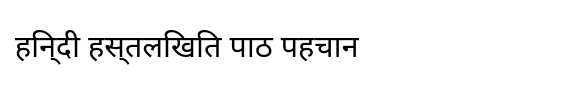

In [4]:
import urllib.request
import warnings

# Suppress the harmless missing-glyph warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font")

FONT_DIR = Path("/kaggle/working/fonts")
FONT_DIR.mkdir(parents=True, exist_ok=True)
FONT_PATH = FONT_DIR / "NotoSansDevanagari-Regular.ttf"
FONT_URL = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"

LOCAL_FONT_CANDIDATES = [
    Path("/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf"),
    Path("/usr/share/fonts/opentype/noto/NotoSansDevanagari-Regular.ttf"),
    Path("/usr/share/fonts/truetype/lohit-devanagari/Lohit-Devanagari.ttf"),
]

if not FONT_PATH.exists():
    copied = False
    for candidate in LOCAL_FONT_CANDIDATES:
        if candidate.exists():
            FONT_PATH.write_bytes(candidate.read_bytes())
            copied = True
            print("Copied local font:", candidate)
            break
    if not copied:
        print("Downloading Noto Sans Devanagari...")
        urllib.request.urlretrieve(FONT_URL, FONT_PATH)

fm.fontManager.addfont(str(FONT_PATH))
DEVANAGARI_FONT_PROP = fm.FontProperties(fname=str(FONT_PATH))

# Force default Latin font back — clear any previous Devanagari override
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
mpl.rcParams["axes.unicode_minus"] = False

# Clear matplotlib font cache to pick up the reset
fm._load_fontmanager(try_read_cache=False)

print("Font file:", FONT_PATH)

plt.figure(figsize=(7, 1.2))
plt.text(0.01, 0.5, "हिन्दी हस्तलिखित पाठ पहचान", fontsize=22, fontproperties=DEVANAGARI_FONT_PROP)
plt.axis("off")
plt.show()


## 5. Verify Dataset Files

This cell verifies that Kaggle can see all five Parquet files.

In [5]:
all_files = TRAIN_FILES + VAL_FILES + TEST_FILES
missing_files = [str(path) for path in all_files if not path.exists()]

if missing_files:
    raise FileNotFoundError("Missing dataset files:\n" + "\n".join(missing_files))

for path in all_files:
    print(f"{path}  ({path.stat().st_size / (1024 * 1024):.2f} MB)")

/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset/train data 1.parquet  (439.31 MB)
/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset/train data 2.parquet  (440.03 MB)
/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset/train data 3.parquet  (438.01 MB)
/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset/val data.parquet  (246.04 MB)
/kaggle/input/datasets/nehamalik10/hindi-ocr-dataset/test data.parquet  (243.14 MB)


## 6. Load Train, Validation, and Test Splits

The split is already provided. We load it exactly as given and verify the expected sample counts.

In [6]:
train_df = pd.concat([pd.read_parquet(path) for path in TRAIN_FILES], ignore_index=True)
val_df = pd.read_parquet(VAL_FILES[0])
test_df = pd.read_parquet(TEST_FILES[0])

split_sizes = {
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df),
}

print("Split sizes:")
for split_name, count in split_sizes.items():
    expected = EXPECTED_SPLIT_SIZES[split_name]
    status = "OK" if count == expected else f"EXPECTED {expected}"
    print(f"  {split_name:5s}: {count:,}  [{status}]")

with (ARTIFACT_DIR / "split_sizes.json").open("w", encoding="utf-8") as f:
    json.dump(split_sizes, f, indent=2)

print("\nColumns:", train_df.columns.tolist())
print("\nDtypes:")
print(train_df.dtypes)

Split sizes:
  train: 69,853  [OK]
  val  : 12,708  [OK]
  test : 12,869  [OK]

Columns: ['image', 'text']

Dtypes:
image    object
text     object
dtype: object


## 7. Detect Image and Label Columns

This detects the image column and label column automatically. It works for common Hugging Face Parquet formats where image data may be stored as bytes or dictionaries.

In [7]:
def detect_columns(frame: pd.DataFrame) -> tuple[str, str]:
    sample = frame.iloc[0]
    image_col = None
    label_col = None

    print("Row 0 field inspection:")
    for col in frame.columns:
        value = sample[col]
        value_type = type(value).__name__
        if isinstance(value, dict) and ("bytes" in value or "path" in value):
            image_col = image_col or col
            print(f"  {col}: dict image field -> IMAGE")
        elif isinstance(value, (bytes, bytearray)):
            image_col = image_col or col
            print(f"  {col}: bytes -> IMAGE")
        elif isinstance(value, Image.Image):
            image_col = image_col or col
            print(f"  {col}: PIL Image -> IMAGE")
        elif isinstance(value, str):
            label_col = label_col or col
            print(f"  {col}: str={value[:80]!r} -> possible LABEL")
        else:
            print(f"  {col}: {value_type}")

    if image_col is None:
        for candidate in ["image", "img", "pixel_values", "path", "image_path", "file", "filename"]:
            if candidate in frame.columns:
                image_col = candidate
                break

    if label_col is None:
        for candidate in ["text", "label", "labels", "transcription", "word", "ground_truth", "gt"]:
            if candidate in frame.columns:
                label_col = candidate
                break

    if image_col is None or label_col is None:
        raise ValueError(f"Could not detect image/label columns. Found columns: {frame.columns.tolist()}")

    return image_col, label_col

IMG_COL, LABEL_COL = detect_columns(train_df)
print("\nImage column:", IMG_COL)
print("Label column:", LABEL_COL)

non_image_cols = [col for col in train_df.columns if col != IMG_COL]
display(train_df[non_image_cols].head())

Row 0 field inspection:
  image: dict image field -> IMAGE
  text: str='केंद्रों' -> possible LABEL

Image column: image
Label column: text


,text
0,केंद्रों
1,फ़त्तू
2,सैटल
3,थाने
4,इंडियन


## 8. Image Decoding Helper

This helper converts each row's image field into a PIL image. All downstream preprocessing uses this function.

Sample image size: (587, 293)
Sample label: केंद्रों


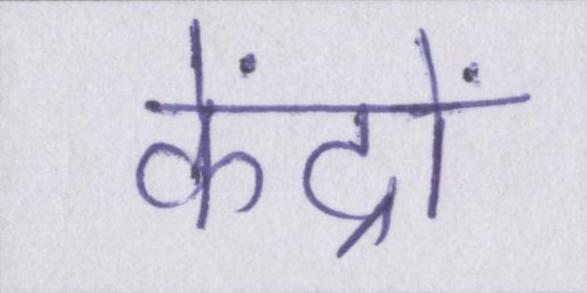

In [8]:
def row_to_image(row: pd.Series, image_col: str = IMG_COL) -> Image.Image:
    value = row[image_col]

    if isinstance(value, Image.Image):
        return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    if isinstance(value, (str, Path)):
        return Image.open(value).convert("RGB")

    raise TypeError(f"Unsupported image value type: {type(value)!r}")

sample_image = row_to_image(train_df.iloc[0])
print("Sample image size:", sample_image.size)
print("Sample label:", train_df.iloc[0][LABEL_COL])
display(sample_image)

## 9. Visualize Raw Training Samples

This confirms that the images and labels match before preprocessing.

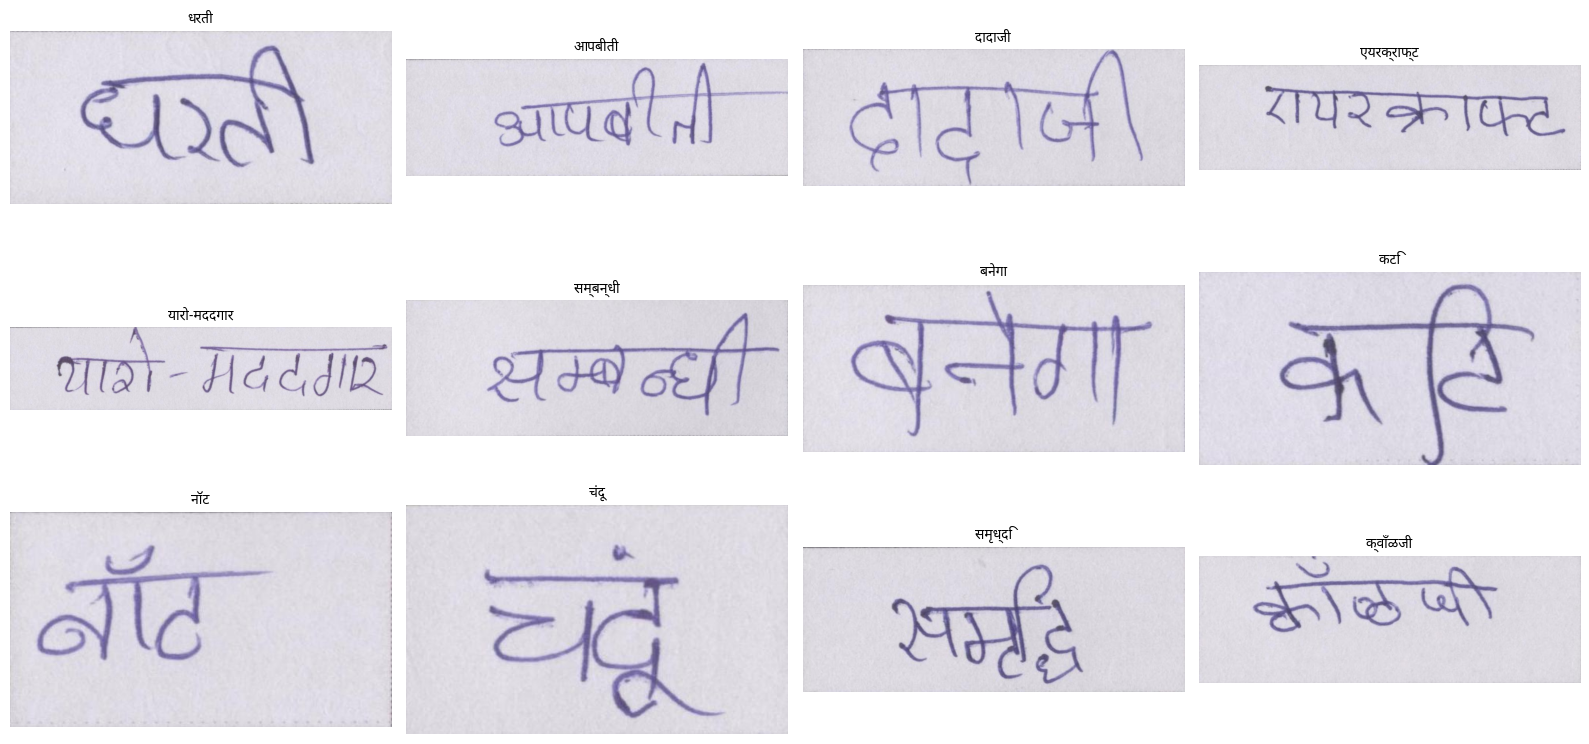

In [9]:
sample_count = min(12, len(train_df))
sample_indices = np.random.choice(len(train_df), sample_count, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()
for axis, idx in zip(axes, sample_indices):
    row = train_df.iloc[idx]
    axis.imshow(row_to_image(row))
    axis.set_title(str(row[LABEL_COL]), fontsize=12, fontproperties=DEVANAGARI_FONT_PROP)
    axis.axis("off")
for axis in axes[sample_count:]:
    axis.axis("off")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "raw_samples.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Image Dimension Analysis

This checks whether the images are word-level crops and how much aspect-ratio variation exists. This matters because naive stretching can distort handwriting.

,width,height,aspect_ratio
count,3000.000000,3000.000000,3000.000000
mean,768.801000,292.705000,2.626251
std,195.026882,1.830417,0.664966
min,319.000000,250.000000,1.092466
25%,633.000000,292.000000,2.164243
50%,744.500000,293.000000,2.544521
75%,876.000000,293.000000,2.993151
max,1986.000000,322.000000,6.778157


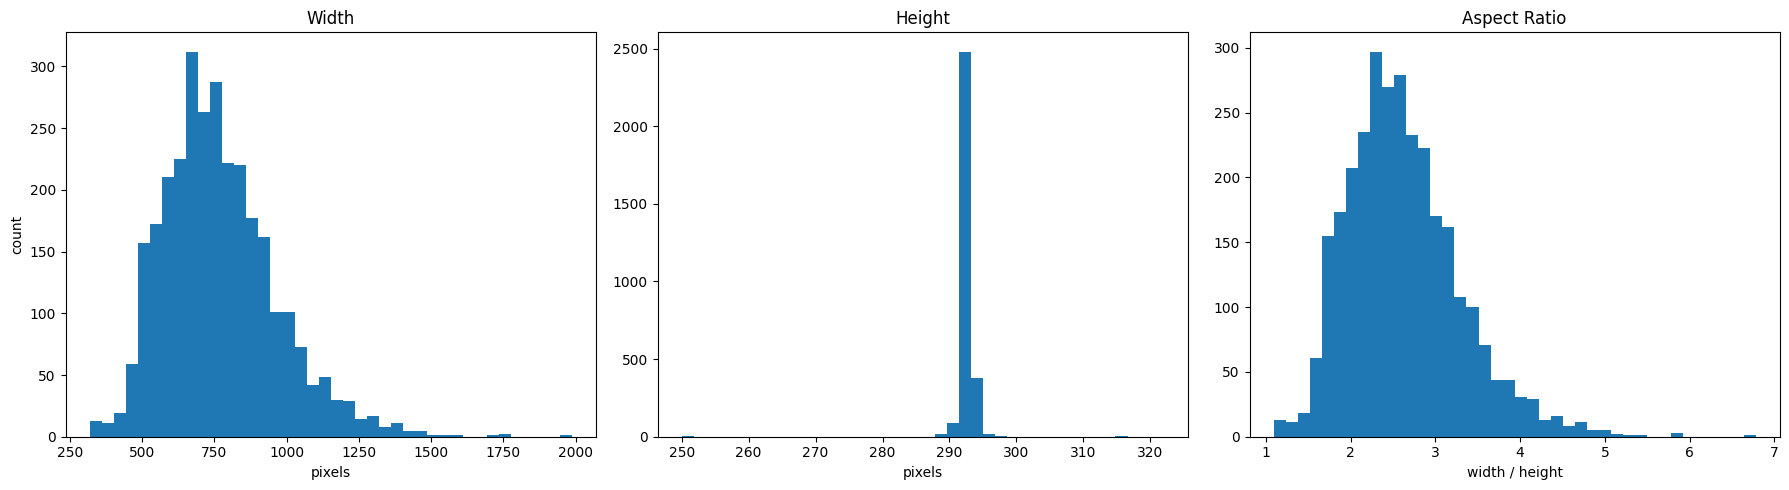

In [10]:
dim_sample_size = min(3000, len(train_df))
dim_indices = np.random.choice(len(train_df), dim_sample_size, replace=False)

rows = []
for idx in dim_indices:
    img = row_to_image(train_df.iloc[idx])
    w, h = img.size
    rows.append({"width": w, "height": h, "aspect_ratio": w / max(h, 1)})

dim_df = pd.DataFrame(rows)
display(dim_df.describe())
dim_df.to_csv(ARTIFACT_DIR / "image_dimension_sample.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(dim_df["width"], bins=40)
axes[0].set_title("Width")
axes[0].set_xlabel("pixels")
axes[0].set_ylabel("count")
axes[1].hist(dim_df["height"], bins=40)
axes[1].set_title("Height")
axes[1].set_xlabel("pixels")
axes[2].hist(dim_df["aspect_ratio"], bins=40)
axes[2].set_title("Aspect Ratio")
axes[2].set_xlabel("width / height")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "dimension_analysis.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Label Normalization and Character Vocabulary

For CTC training, index `0` is reserved for the blank token. Hindi/Devanagari characters start from index `1`.

We build the vocabulary from **training labels only** to avoid leakage.

In [11]:
def normalize_label(text: Any) -> str:
    text = unicodedata.normalize("NFC", str(text))
    return " ".join(text.strip().split())

train_labels = [normalize_label(x) for x in train_df[LABEL_COL].tolist()]
val_labels = [normalize_label(x) for x in val_df[LABEL_COL].tolist()]
test_labels = [normalize_label(x) for x in test_df[LABEL_COL].tolist()]

char_counter = Counter("".join(train_labels))
characters = sorted(char_counter.keys())

char_to_idx = {BLANK_TOKEN: 0}
for idx, char in enumerate(characters, start=1):
    char_to_idx[char] = idx
char_to_idx[UNK_TOKEN] = len(char_to_idx)
char_to_idx[PAD_TOKEN] = len(char_to_idx)

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
blank_idx = char_to_idx[BLANK_TOKEN]
unk_idx = char_to_idx[UNK_TOKEN]
pad_idx = char_to_idx[PAD_TOKEN]

print("Vocabulary size including special tokens:", len(char_to_idx))
print("CTC blank index:", blank_idx)
print("UNK index:", unk_idx)
print("PAD index:", pad_idx)
print("Most common characters:")
for char, count in char_counter.most_common(25):
    visible = "SPACE" if char == " " else char
    print(f"  {visible!r}: {count:,}")

vocab_payload = {
    "char_to_idx": char_to_idx,
    "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
    "blank_idx": blank_idx,
    "unk_idx": unk_idx,
    "pad_idx": pad_idx,
    "unicode_normalization": "NFC",
}
with (ARTIFACT_DIR / "char_vocab.json").open("w", encoding="utf-8") as f:
    json.dump(vocab_payload, f, ensure_ascii=False, indent=2)

print("Saved:", ARTIFACT_DIR / "char_vocab.json")

Vocabulary size including special tokens: 103
CTC blank index: 0
UNK index: 101
PAD index: 102
Most common characters:
  'ा': 38,075
  'र': 27,660
  '्': 26,771
  'न': 17,642
  'ि': 17,586
  'क': 16,844
  'े': 15,883
  'स': 15,431
  'त': 15,361
  'ं': 15,141
  'ी': 14,701
  'ल': 13,504
  'म': 13,123
  'प': 11,178
  'ो': 10,933
  'व': 10,225
  'य': 10,175
  'द': 8,963
  'ज': 8,601
  'ग': 8,151
  'ब': 7,968
  'ु': 7,728
  'ह': 7,072
  'ट': 6,504
  'ड': 5,583
Saved: /kaggle/working/phase2_preprocessing/artifacts/char_vocab.json


## 12. Label Length and Unicode Analysis

This catches important Hindi-specific issues such as very long labels, unexpected punctuation, or combining marks.

Train label length summary:


count    69853.000000
mean         6.005669
std          2.258618
min          1.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         23.000000
Name: label_length, dtype: float64

Unknown chars in val: []
Unknown chars in test: []


/tmp/ipykernel_57/2422408092.py:35: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_57/2422408092.py:36: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.savefig(PREVIEW_DIR / "label_unicode_analysis.png", dpi=160, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)


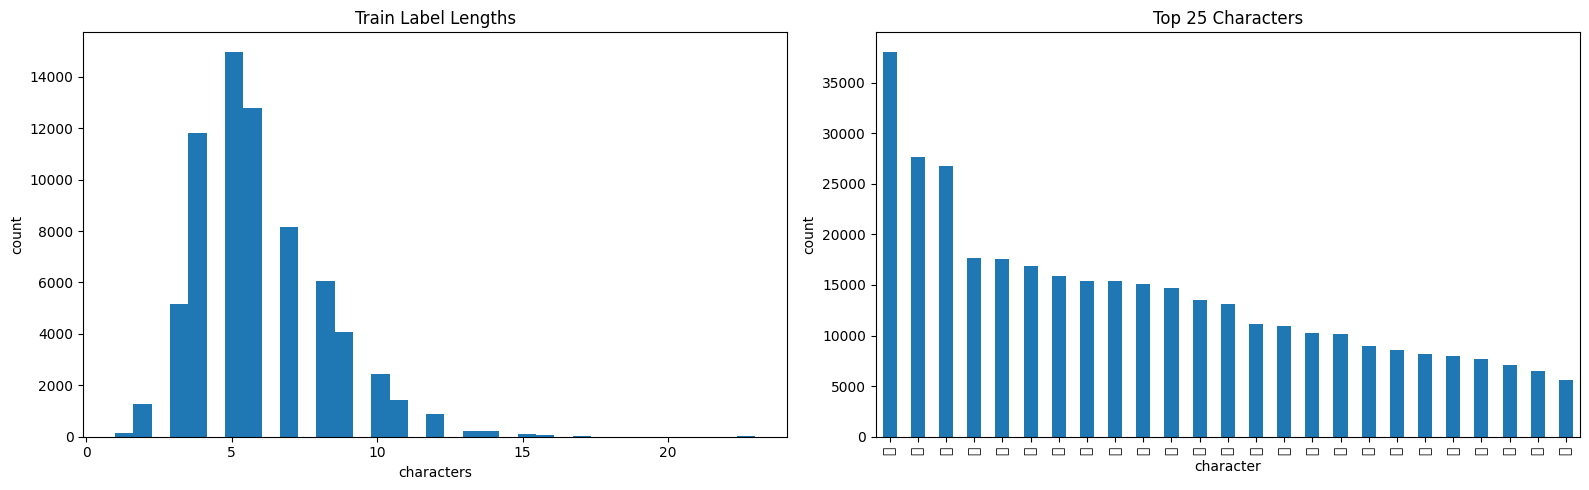

,char,codepoint,category,name,count
59,ा,U+093E,Mc,DEVANAGARI VOWEL SIGN AA,38075
47,र,U+0930,Lo,DEVANAGARI LETTER RA,27660
73,्,U+094D,Mn,DEVANAGARI SIGN VIRAMA,26771
39,न,U+0928,Lo,DEVANAGARI LETTER NA,17642
60,ि,U+093F,Mc,DEVANAGARI VOWEL SIGN I,17586
20,क,U+0915,Lo,DEVANAGARI LETTER KA,16844
67,े,U+0947,Mn,DEVANAGARI VOWEL SIGN E,15883
55,स,U+0938,Lo,DEVANAGARI LETTER SA,15431
35,त,U+0924,Lo,DEVANAGARI LETTER TA,15361
2,ं,U+0902,Mn,DEVANAGARI SIGN ANUSVARA,15141


In [12]:
label_lengths = pd.Series([len(label) for label in train_labels], name="label_length")
print("Train label length summary:")
display(label_lengths.describe())

unicode_rows = []
for char in characters:
    unicode_rows.append({
        "char": char,
        "codepoint": f"U+{ord(char):04X}",
        "category": unicodedata.category(char),
        "name": unicodedata.name(char, "UNKNOWN"),
        "count": char_counter[char],
    })
unicode_df = pd.DataFrame(unicode_rows).sort_values("count", ascending=False)
unicode_df.to_csv(ARTIFACT_DIR / "unicode_character_analysis.csv", index=False, encoding="utf-8")

def unknown_chars(labels: list[str]) -> set[str]:
    known = set(characters)
    return set("".join(labels)) - known

val_unknown = unknown_chars(val_labels)
test_unknown = unknown_chars(test_labels)
print("Unknown chars in val:", sorted(val_unknown))
print("Unknown chars in test:", sorted(test_unknown))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(label_lengths, bins=35)
axes[0].set_title("Train Label Lengths")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("count")
unicode_df.head(25).plot(kind="bar", x="char", y="count", ax=axes[1], legend=False)
axes[1].set_title("Top 25 Characters")
axes[1].set_xlabel("character")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "label_unicode_analysis.png", dpi=160, bbox_inches="tight")
plt.show()

display(unicode_df.head(20))

## 13. Core Image Preprocessing Functions

Required pipeline:

1. Convert to grayscale
2. Denoise and improve contrast
3. Deskew correction
4. **Tight crop** — crop to bounding box of text (removes white margins)
5. Binarize using Otsu or adaptive thresholding *(skipped when `SKIP_BINARIZATION=True` for Transformer models)*
6. Inversion check (ensure dark-on-light)
7. Resize to **32×128** with aspect-ratio padding
8. Normalize to `[-1, 1]`

The final tensor shape is `(1, 32, 128)`.

In [13]:
def pil_to_gray_np(image: Image.Image) -> np.ndarray:
    return np.array(image.convert("L"))

def autocontrast_gray(gray: np.ndarray) -> np.ndarray:
    return np.array(ImageOps.autocontrast(Image.fromarray(gray)))

def denoise_gray(gray: np.ndarray) -> np.ndarray:
    return cv2.medianBlur(gray, 3)

def binarize_gray(gray: np.ndarray, mode: str = BINARIZATION_MODE) -> np.ndarray:
    if mode == "otsu":
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif mode == "adaptive":
        binary = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            21,
            11,
        )
    else:
        raise ValueError(f"Unsupported binarization mode: {mode}")
    return binary

def ensure_black_text(img: np.ndarray) -> np.ndarray:
    """Ensure text is dark on light background."""
    dark_ratio = np.mean(img < 128)
    if INVERT_IMAGE or dark_ratio > 0.55:
        return 255 - img
    return img

def deskew_image(img: np.ndarray) -> np.ndarray:
    """Correct skew using minAreaRect on dark-pixel contours."""
    coords = np.column_stack(np.where(img < 128))
    if len(coords) < 10:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    if abs(angle) > 8:
        return img
    h, w = img.shape
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, matrix, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)

def tight_crop(img: np.ndarray, pad: int = TIGHT_CROP_PAD) -> np.ndarray:
    """Crop image to bounding box of ink pixels plus padding.

    This prevents massive white margins from shrinking the actual text
    to unreadable size after resizing to 32x128.
    """
    coords = np.column_stack(np.where(img < 200))
    if len(coords) == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad + 1)
    x1 = min(img.shape[1], x1 + pad + 1)
    cropped = img[y0:y1, x0:x1]
    if cropped.size == 0:
        return img
    return cropped

def resize_with_padding(img: np.ndarray, target_h: int = IMG_HEIGHT, target_w: int = IMG_WIDTH) -> np.ndarray:
    h, w = img.shape
    if h <= 0 or w <= 0:
        return np.full((target_h, target_w), 255, dtype=np.uint8)

    if KEEP_ASPECT_RATIO:
        scale = min(target_w / w, target_h / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        canvas = np.full((target_h, target_w), 255, dtype=np.uint8)
        x0 = (target_w - new_w) // 2
        y0 = (target_h - new_h) // 2
        canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
        return canvas

    return cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32) / 255.0
    image = (image - 0.5) / 0.5
    return image

def preprocess_image(image: Image.Image, return_steps: bool = False) -> np.ndarray | dict[str, np.ndarray]:
    """Complete preprocessing pipeline.

    Order: grayscale -> contrast -> denoise -> deskew -> tight_crop
           -> [conditional binarize] -> inversion check -> resize -> normalize

    When SKIP_BINARIZATION is True (for Transformer models like TrOCR),
    binarization is skipped and the model receives raw grayscale with
    subtle anti-aliasing information preserved.
    """
    # 1. Grayscale
    gray = pil_to_gray_np(image)
    # 2. Contrast normalization
    contrast = autocontrast_gray(gray)
    # 3. Noise removal
    denoised = denoise_gray(contrast)
    # 4. Deskew
    deskewed = deskew_image(denoised)
    # 5. Tight crop (remove excess whitespace before resize)
    cropped = tight_crop(deskewed)

    # 6-7. Conditional binarization + inversion check
    if SKIP_BINARIZATION:
        # Keep grayscale for Transformer models
        processed = ensure_black_text(cropped)
    else:
        # Binarize for CRNN
        binary = binarize_gray(cropped, mode=BINARIZATION_MODE)
        processed = ensure_black_text(binary)

    # 8. Resize with aspect-ratio padding
    resized = resize_with_padding(processed, IMG_HEIGHT, IMG_WIDTH)
    # 9. Normalize to [-1, 1]
    normalized = normalize_image(resized)
    # 10. Add channel dimension
    tensor_image = normalized[np.newaxis, :, :]

    if return_steps:
        return {
            "gray": gray,
            "contrast": contrast,
            "denoised": denoised,
            "deskewed": deskewed,
            "cropped": cropped,
            "processed": processed,
            "resized": resized,
            "normalized": normalized,
            "tensor": tensor_image,
        }
    return tensor_image

## 14. Preprocessing Step-by-Step Preview

This visualizes each preprocessing stage for a few samples. This is the key Phase 2 evidence cell.

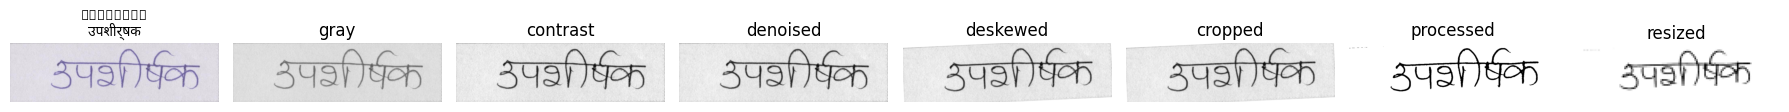

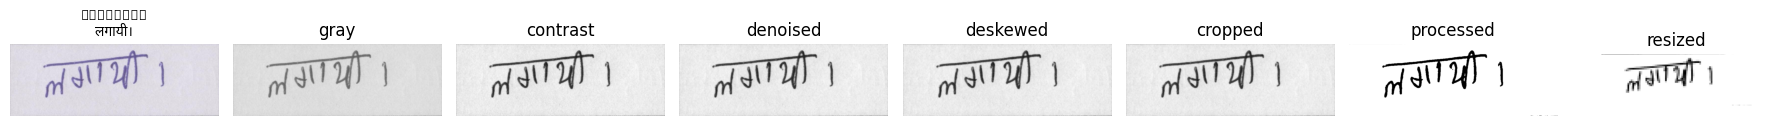

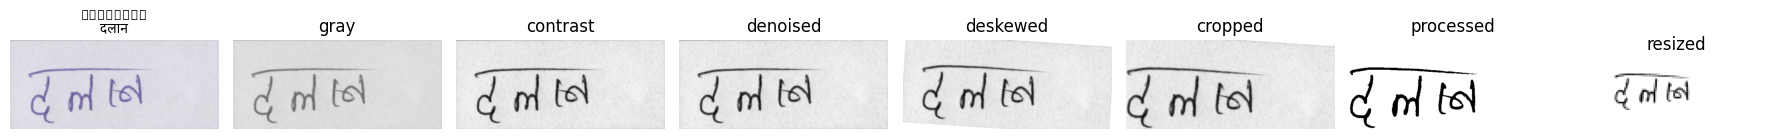

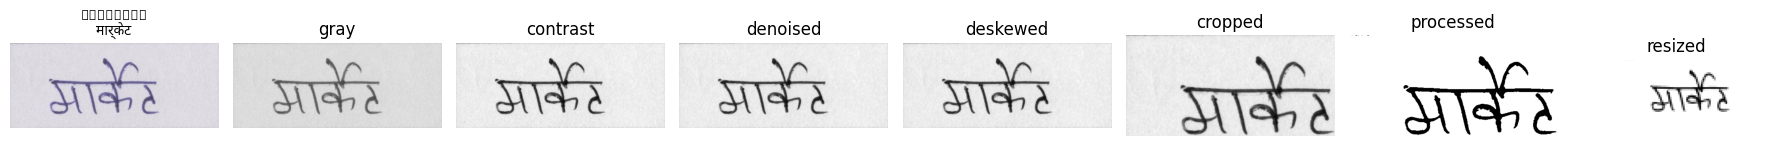

In [14]:
preview_indices = np.random.choice(len(train_df), min(4, len(train_df)), replace=False)
stage_names = ["gray", "contrast", "denoised", "deskewed", "cropped", "processed", "resized"]

for sample_number, idx in enumerate(preview_indices, start=1):
    row = train_df.iloc[idx]
    image = row_to_image(row)
    steps = preprocess_image(image, return_steps=True)
    label = normalize_label(row[LABEL_COL])

    fig, axes = plt.subplots(1, len(stage_names) + 1, figsize=(18, 3))
    axes[0].imshow(image)
    axes[0].set_title(f"Original\n{label}", fontproperties=DEVANAGARI_FONT_PROP)
    axes[0].axis("off")

    for axis, name in zip(axes[1:], stage_names):
        axis.imshow(steps[name], cmap="gray", vmin=0, vmax=255)
        axis.set_title(name)
        axis.axis("off")

    plt.tight_layout()
    plt.savefig(PREVIEW_DIR / f"preprocessing_steps_{sample_number}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 15. Data Augmentation Functions

Training augmentation includes:

- Rotation between `-5°` and `+5°`
- Elastic distortion
- Noise addition
- Small erosion/dilation variations
- **Shear/slant transformation** (±12° — simulates different handwriting slants)
- **Cutout/coarse dropout** (random 4×4 pixel blocks — simulates faded ink)

These augmentations are applied only to the training dataset.

In [15]:
def random_rotation(image: np.ndarray, max_angle: float = 5.0) -> np.ndarray:
    angle = random.uniform(-max_angle, max_angle)
    h, w = image.shape
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(image, matrix, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def elastic_distortion(image: np.ndarray, alpha: float = 7.0, sigma: float = 4.0) -> np.ndarray:
    h, w = image.shape
    dx = np.random.uniform(-1, 1, (h, w)).astype(np.float32)
    dy = np.random.uniform(-1, 1, (h, w)).astype(np.float32)
    dx = cv2.GaussianBlur(dx, (0, 0), sigma) * alpha
    dy = cv2.GaussianBlur(dy, (0, 0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = (x + dx).astype(np.float32)
    map_y = (y + dy).astype(np.float32)
    return cv2.remap(image, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def add_noise(image: np.ndarray, std: float = 10.0) -> np.ndarray:
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_erode_dilate(image: np.ndarray) -> np.ndarray:
    kernel = np.ones((2, 2), np.uint8)
    if random.random() < 0.5:
        return cv2.erode(image, kernel, iterations=1)
    return cv2.dilate(image, kernel, iterations=1)

def random_shear(image: np.ndarray, max_shear_deg: float = 12.0) -> np.ndarray:
    """Apply affine shear (slant) transformation.

    Simulates different handwriting slants by tilting the vertical axis.
    A shear of +-12 degrees covers most cursive writing styles.
    """
    h, w = image.shape
    shear_rad = np.radians(random.uniform(-max_shear_deg, max_shear_deg))
    # Affine shear matrix: [[1, shear, 0], [0, 1, 0]]
    M = np.array([[1, shear_rad, 0],
                  [0, 1, 0]], dtype=np.float32)
    # Shift to keep image centered after shear
    M[0, 2] = -shear_rad * h / 2
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def random_cutout(image: np.ndarray, num_patches: int = 3, patch_size: int = 4) -> np.ndarray:
    """Drop random small pixel blocks (coarse dropout).

    Simulates faded ink, paper damage, or partially erased strokes.
    Each patch is a patch_size x patch_size block filled with background (255).
    """
    result = image.copy()
    h, w = result.shape
    for _ in range(random.randint(1, num_patches)):
        y = random.randint(0, max(0, h - patch_size))
        x = random.randint(0, max(0, w - patch_size))
        result[y:y + patch_size, x:x + patch_size] = 255
    return result

def augment_image(image: np.ndarray) -> np.ndarray:
    """Apply random augmentations to a preprocessed image.

    Includes: rotation, elastic distortion, noise, erode/dilate,
    shear/slant, and cutout/coarse dropout.
    """
    augmented = image.copy()
    if random.random() < AUGMENT_ROTATE_PROB:
        augmented = random_rotation(augmented, max_angle=5.0)
    if random.random() < AUGMENT_ELASTIC_PROB:
        augmented = elastic_distortion(augmented)
    if random.random() < AUGMENT_NOISE_PROB:
        augmented = add_noise(augmented)
    if random.random() < AUGMENT_ERODE_DILATE_PROB:
        augmented = random_erode_dilate(augmented)
    if random.random() < AUGMENT_SHEAR_PROB:
        augmented = random_shear(augmented)
    if random.random() < AUGMENT_CUTOUT_PROB:
        augmented = random_cutout(augmented)
    return augmented

## 16. Augmentation Preview

This confirms that augmentation is realistic and does not destroy Devanagari strokes.

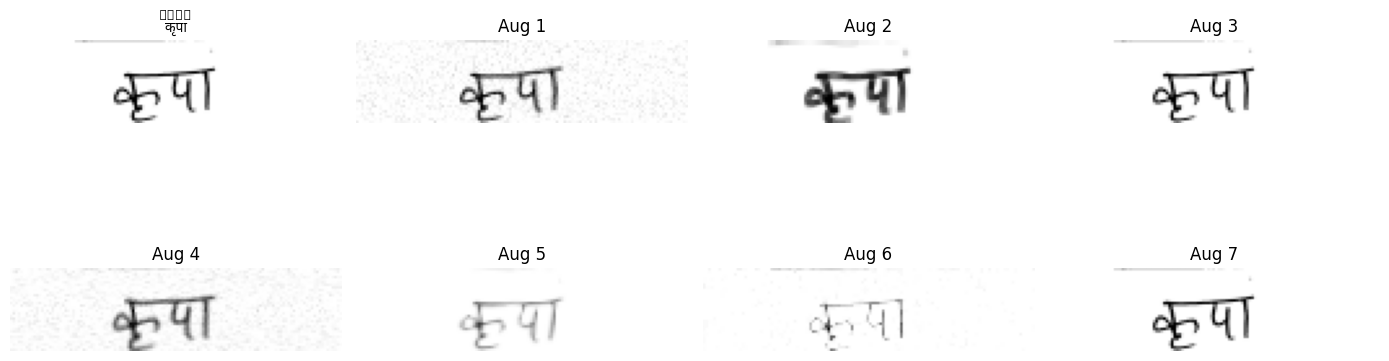

In [16]:
row = train_df.iloc[np.random.randint(0, len(train_df))]
image = row_to_image(row)
steps = preprocess_image(image, return_steps=True)
base = steps["resized"]
label = normalize_label(row[LABEL_COL])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(base, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Base\n{label}", fontproperties=DEVANAGARI_FONT_PROP)
axes[0].axis("off")

for i in range(1, len(axes)):
    aug = augment_image(base)
    axes[i].imshow(aug, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(PREVIEW_DIR / "augmentation_preview.png", dpi=160, bbox_inches="tight")
plt.show()

## 17. Label Encoding and Decoding

This converts Hindi labels into integer sequences for CTC training and provides a decoder for sanity checks.

In [17]:
def encode_label(label: Any) -> list[int]:
    label = normalize_label(label)
    return [char_to_idx.get(char, unk_idx) for char in label]

def decode_indices(indices: list[int]) -> str:
    chars = []
    for idx in indices:
        if idx in {blank_idx, pad_idx}:
            continue
        chars.append(idx_to_char.get(int(idx), ""))
    return "".join(chars)

example_label = train_labels[0]
encoded = encode_label(example_label)
decoded = decode_indices(encoded)
print("Label:  ", example_label)
print("Encoded:", encoded)
print("Decoded:", decoded)

Label:   केंद्रों
Encoded: [21, 68, 3, 38, 74, 48, 72, 3]
Decoded: केंद्रों


## 18. PyTorch Dataset Class

This class returns:

- `image`: tensor of shape `(1, 32, 128)`
- `label`: integer tensor of variable length
- `label_length`: label length for CTC
- `text`: original normalized label

Augmentation is enabled only for the training dataset.

In [18]:
class HindiHTRDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, image_col: str, label_col: str, augment: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.augment = augment

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> dict[str, Any]:
        row = self.frame.iloc[index]
        image = row_to_image(row, self.image_col)
        steps = preprocess_image(image, return_steps=True)
        resized = steps["resized"]

        if self.augment:
            resized = augment_image(resized)

        normalized = normalize_image(resized)
        image_tensor = torch.from_numpy(normalized).unsqueeze(0).float()

        text = normalize_label(row[self.label_col])
        label_ids = torch.tensor(encode_label(text), dtype=torch.long)

        return {
            "image": image_tensor,
            "label": label_ids,
            "label_length": len(label_ids),
            "text": text,
            "index": index,
        }

train_dataset = HindiHTRDataset(train_df, IMG_COL, LABEL_COL, augment=True)
val_dataset = HindiHTRDataset(val_df, IMG_COL, LABEL_COL, augment=False)
test_dataset = HindiHTRDataset(test_df, IMG_COL, LABEL_COL, augment=False)

sample = train_dataset[0]
print("Image tensor:", sample["image"].shape, sample["image"].dtype, sample["image"].min().item(), sample["image"].max().item())
print("Label tensor:", sample["label"])
print("Label length:", sample["label_length"])
print("Text:", sample["text"])

Image tensor: torch.Size([1, 32, 128]) torch.float32 -1.0 1.0
Label tensor: tensor([21, 68,  3, 38, 74, 48, 72,  3])
Label length: 8
Text: केंद्रों


## 19. DataLoader and Collate Function

Labels have variable lengths, so the collate function pads them with `PAD_TOKEN`. It also returns `label_lengths`, which is needed for CTC loss.

In [19]:
def htr_collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
    images = torch.stack([item["image"] for item in batch])
    label_lengths = torch.tensor([item["label_length"] for item in batch], dtype=torch.long)
    max_len = int(label_lengths.max().item()) if len(label_lengths) else 0

    labels = torch.full((len(batch), max_len), fill_value=pad_idx, dtype=torch.long)
    for i, item in enumerate(batch):
        label = item["label"]
        labels[i, : len(label)] = label

    texts = [item["text"] for item in batch]
    indices = torch.tensor([item["index"] for item in batch], dtype=torch.long)

    return {
        "images": images,
        "labels": labels,
        "label_lengths": label_lengths,
        "texts": texts,
        "indices": indices,
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=htr_collate_fn,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=htr_collate_fn,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=htr_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(train_loader))
print("images:", batch["images"].shape, batch["images"].dtype)
print("labels:", batch["labels"].shape, batch["labels"].dtype)
print("label_lengths:", batch["label_lengths"].shape)
print("first texts:", batch["texts"][:5])

images: torch.Size([32, 1, 32, 128]) torch.float32
labels: torch.Size([32, 9]) torch.int64
label_lengths: torch.Size([32])
first texts: ['निर्भर', 'ई-केवाईसी', 'आखिर', 'खामी', 'लिंडहेगन']


## 20. Batch Visualization

This shows one DataLoader batch after preprocessing and augmentation. The image values are converted back from `[-1, 1]` for display.

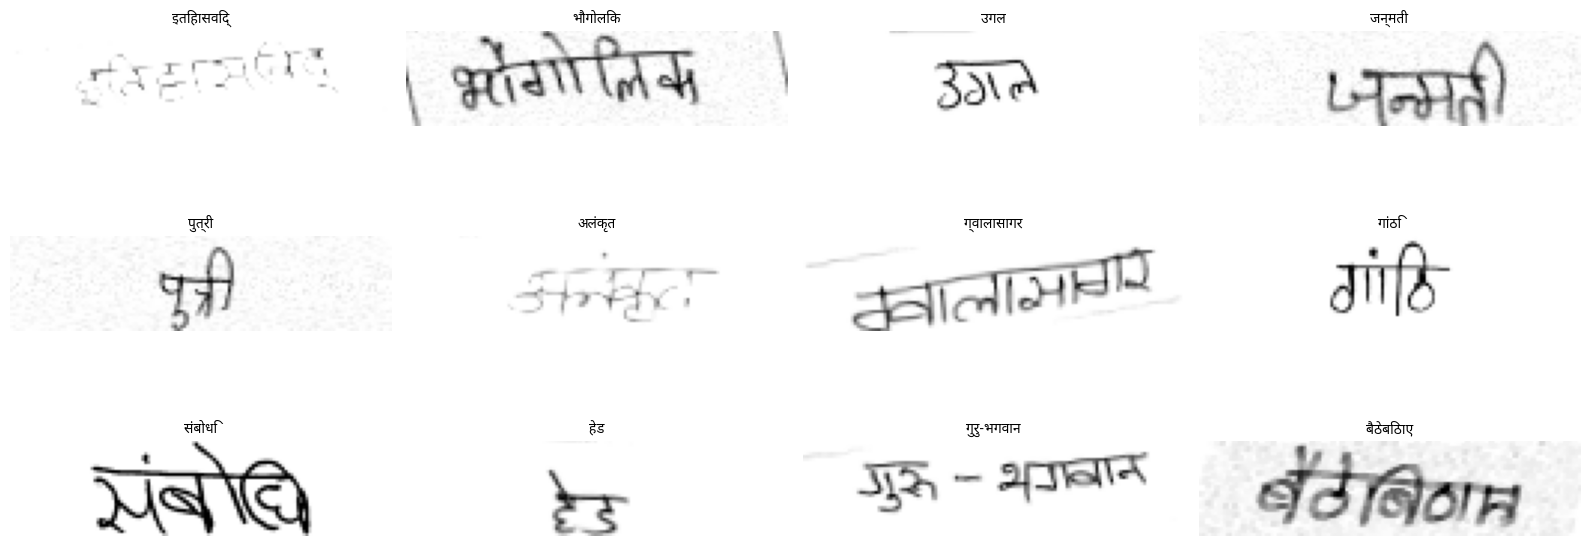

In [20]:
def tensor_to_display_image(tensor: torch.Tensor) -> np.ndarray:
    image = tensor.squeeze(0).detach().cpu().numpy()
    image = ((image * 0.5) + 0.5) * 255.0
    return np.clip(image, 0, 255).astype(np.uint8)

batch = next(iter(train_loader))
show_count = min(12, batch["images"].shape[0])
fig, axes = plt.subplots(3, 4, figsize=(16, 7))
axes = axes.flatten()
for i in range(show_count):
    axes[i].imshow(tensor_to_display_image(batch["images"][i]), cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(batch["texts"][i], fontsize=11, fontproperties=DEVANAGARI_FONT_PROP)
    axes[i].axis("off")
for axis in axes[show_count:]:
    axis.axis("off")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "processed_batch_preview.png", dpi=160, bbox_inches="tight")
plt.show()

## 21. Save Pipeline Configuration and Sample Batch

This writes the Phase 2 deliverables to `/kaggle/working/phase2_preprocessing`.

In [21]:
pipeline_config = {
    "image_height": IMG_HEIGHT,
    "image_width": IMG_WIDTH,
    "binarization_mode": BINARIZATION_MODE,
    "invert_image": INVERT_IMAGE,
    "keep_aspect_ratio": KEEP_ASPECT_RATIO,
    "normalization": "image / 255 -> (x - 0.5) / 0.5, range [-1, 1]",
    "blank_token": BLANK_TOKEN,
    "unk_token": UNK_TOKEN,
    "pad_token": PAD_TOKEN,
    "blank_idx": blank_idx,
    "unk_idx": unk_idx,
    "pad_idx": pad_idx,
    "batch_size": BATCH_SIZE,
    "augmentations": {
        "rotation_degrees": [-5, 5],
        "elastic_distortion": True,
        "noise_addition": True,
        "erode_dilate": True,
        "shear_slant_degrees": [-12, 12],
        "cutout_coarse_dropout": True,
    },
    "skip_binarization": SKIP_BINARIZATION,
    "tight_crop_pad": TIGHT_CROP_PAD,
    "split_sizes": split_sizes,
    "image_column": IMG_COL,
    "label_column": LABEL_COL,
}

with (ARTIFACT_DIR / "preprocess_config.json").open("w", encoding="utf-8") as f:
    json.dump(pipeline_config, f, ensure_ascii=False, indent=2)

sample_batch = next(iter(train_loader))
torch.save(
    {
        "images": sample_batch["images"],
        "labels": sample_batch["labels"],
        "label_lengths": sample_batch["label_lengths"],
        "texts": sample_batch["texts"],
    },
    ARTIFACT_DIR / "sample_train_batch.pt",
)

print("Saved artifacts:")
for path in sorted(ARTIFACT_DIR.glob("*")):
    print(" -", path)
print("\nSaved previews:")
for path in sorted(PREVIEW_DIR.glob("*")):
    print(" -", path)

Saved artifacts:
 - /kaggle/working/phase2_preprocessing/artifacts/char_vocab.json
 - /kaggle/working/phase2_preprocessing/artifacts/image_dimension_sample.csv
 - /kaggle/working/phase2_preprocessing/artifacts/preprocess_config.json
 - /kaggle/working/phase2_preprocessing/artifacts/sample_train_batch.pt
 - /kaggle/working/phase2_preprocessing/artifacts/split_sizes.json
 - /kaggle/working/phase2_preprocessing/artifacts/unicode_character_analysis.csv

Saved previews:
 - /kaggle/working/phase2_preprocessing/previews/augmentation_preview.png
 - /kaggle/working/phase2_preprocessing/previews/dimension_analysis.png
 - /kaggle/working/phase2_preprocessing/previews/label_unicode_analysis.png
 - /kaggle/working/phase2_preprocessing/previews/preprocessing_steps_1.png
 - /kaggle/working/phase2_preprocessing/previews/preprocessing_steps_2.png
 - /kaggle/working/phase2_preprocessing/previews/preprocessing_steps_3.png
 - /kaggle/working/phase2_preprocessing/previews/preprocessing_steps_4.png
 - /kagg

## 22. Final Phase 2 Checklist

Run this cell at the end. It prints the deliverable checklist for your weekly update/report.

In [22]:
checklist = {
    "loaded_train_val_test_split": split_sizes == EXPECTED_SPLIT_SIZES,
    "preprocessing_grayscale_binarize_resize_normalize": True,
    "target_shape_32x128": tuple(batch["images"].shape[-2:]) == (IMG_HEIGHT, IMG_WIDTH),
    "character_vocabulary_created": (ARTIFACT_DIR / "char_vocab.json").exists(),
    "pytorch_dataset_created": isinstance(train_dataset, Dataset),
    "pytorch_dataloader_created": isinstance(train_loader, DataLoader),
    "rotation_augmentation_added": True,
    "elastic_distortion_added": True,
    "noise_augmentation_added": True,
    "shear_slant_augmentation_added": True,
    "cutout_dropout_augmentation_added": True,
    "tight_crop_added": True,
    "binarization_toggle_added": True,
    "artifacts_saved": (ARTIFACT_DIR / "preprocess_config.json").exists(),
}

print("=" * 70)
print("PHASE 2 PREPROCESSING PIPELINE SUMMARY")
print("=" * 70)
for item, done in checklist.items():
    print(f"{item:55s}: {'DONE' if done else 'CHECK'}")
print("=" * 70)
print(f"Train / Val / Test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Vocabulary size: {len(char_to_idx):,}")
print(f"Image tensor shape: {tuple(batch['images'].shape)}")
print(f"Artifacts: {ARTIFACT_DIR}")
print(f"Previews: {PREVIEW_DIR}")
print("=" * 70)

with (OUTPUT_DIR / "phase2_checklist.json").open("w", encoding="utf-8") as f:
    json.dump(checklist, f, ensure_ascii=False, indent=2)

PHASE 2 PREPROCESSING PIPELINE SUMMARY
loaded_train_val_test_split                            : DONE
preprocessing_grayscale_binarize_resize_normalize      : DONE
target_shape_32x128                                    : DONE
character_vocabulary_created                           : DONE
pytorch_dataset_created                                : DONE
pytorch_dataloader_created                             : DONE
rotation_augmentation_added                            : DONE
elastic_distortion_added                               : DONE
noise_augmentation_added                               : DONE
shear_slant_augmentation_added                         : DONE
cutout_dropout_augmentation_added                      : DONE
tight_crop_added                                       : DONE
binarization_toggle_added                              : DONE
artifacts_saved                                        : DONE
Train / Val / Test: 69,853 / 12,708 / 12,869
Vocabulary size: 103
Image tensor shape: (32, 1,